# Testing Hypothesis
---
Hypothesis: We can save computing time by pre selecting best copula.

### Importing Iris ds & seperating data

In [82]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)

df = pd.DataFrame(iris.data.features, columns=iris.data.feature_names)
df['targets'] = iris.data.targets

sepal_len = df.loc[df['targets'] == 'Iris-versicolor', 'petal length']
sepal_width = df.loc[df['targets'] == 'Iris-versicolor', 'petal width']
print(df.loc[50])

sepal length                7.0
sepal width                 3.2
petal length                4.7
petal width                 1.4
targets         Iris-versicolor
Name: 50, dtype: object


### Transforming data to percentiles

In [83]:
import numpy as np
from scipy.stats import norm

# For Gaussian marginals assumption:
mean_len = np.mean(sepal_len)
std_len = np.std(sepal_len)

mean_width = np.mean(sepal_width)  
std_width = np.std(sepal_width)

# Transform to uniform via CDF
u = norm.cdf(sepal_len, loc=mean_len, scale=std_len)
v = norm.cdf(sepal_width, loc=mean_width, scale=std_width)

# Clip to avoid 0 or 1 (infinities)
u = np.clip(u, 1e-10, 1-1e-10)
v = np.clip(v, 1e-10, 1-1e-10)

### Gaussian Copula BIC

In [84]:
import sys
sys.path.append('../src')  # Adjust path as needed
from copula_families import GaussianCopula, StudentTCopula, ClaytonCopula, transform_to_uniform

u, v = transform_to_uniform((sepal_len, sepal_width))
gaussian = GaussianCopula()
gaussian.fit(u, v)

bic_gaussian = gaussian.bic(u, v)
print("Gaussian Copula BIC Score:", bic_gaussian)

Gaussian Copula BIC Score: -44.315655704732634


### Student T Copula

In [85]:
student_t = StudentTCopula()
student_t.fit(u, v)

# Calculate BIC first
bic_student = student_t.bic(u, v)
print("Student T Copula BIC Score:", bic_student)

Student T Copula BIC Score: -40.19086772213428


### Clayton Copula

In [86]:
clayton = ClaytonCopula()
clayton.fit(u, v)

# Calculate BIC
bic_clayton = clayton.bic(u, v)
log_lik_clayton = clayton.log_likelihood(u, v)

print(f"Clayton Copula BIC = {bic_clayton}")

Clayton Copula BIC = 25.276714949259954


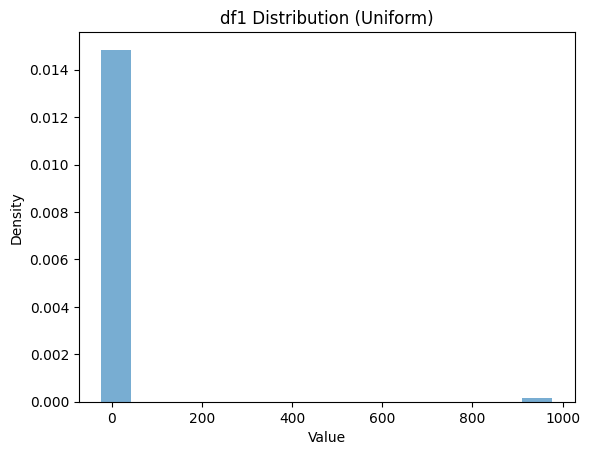

0.0
0.0
Clayton Copula BIC = 4.790244888643333
Student T Copula BIC Score: -19.11193811161396
Gaussian Copula BIC Score: -44.315655704732634


Text(0, 0.5, 'Feature 2 (uniform)')

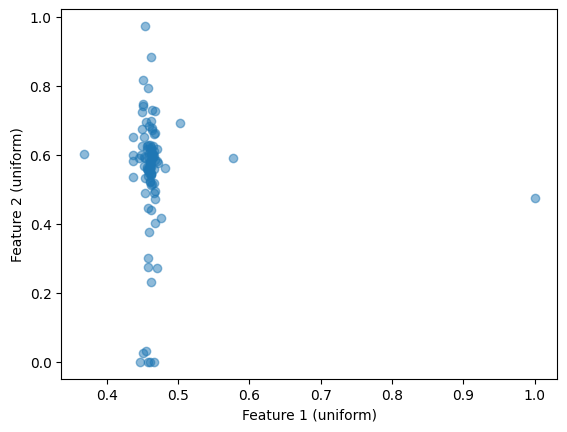

In [ ]:
np.random.seed(45)  # optional, for reproducibility
import matplotlib.pyplot as plt

u = np.random.uniform(0, 1, 100)
# theta = 5  # Higher = stronger tail dependence
# v = (u**(-theta) * (np.random.uniform(0, 1, 100)**(-theta/(1+theta)) - 1) + 1)**(-1/theta)

# df1 = pd.DataFrame({"value": norm.ppf(u) * 10 + 50})  # Scale to 1-100
# df2 = pd.DataFrame({"value": norm.ppf(v) * 10 + 50})

df1 = pd.DataFrame({
    "value": np.random.randint(1, 101, 100)
})

df2 = pd.DataFrame({
    "value": np.random.randint(1, 101, 100)
})


counts, bins = np.histogram(df1['value'], bins=15, density=True)
plt.hist(df1['value'], bins=15, density=True, alpha=0.6)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("df1 Distribution (Uniform)")
plt.show()


# For Gaussian marginals assumption:
mean_len = np.mean(df1['value'])
std_len = np.std(df1['value'])

mean_width = np.mean(df2['value'])  
std_width = np.std(df2['value'])

# Transform to uniform via CDF
u = norm.cdf(df1['value'], loc=mean_len, scale=std_len)
v = norm.cdf(df2['value'], loc=mean_width, scale=std_width)

x = u
y = v

q = 0.1  # Bottom 10%
lower_tail = np.mean((u < q) & (v < q)) / q  # Should be > q for Clayton
upper_tail = np.mean((u > 1-q) & (v > 1-q)) / q  # Should be > q for Student-t
print(lower_tail)
print(upper_tail)

# Clip to avoid 0 or 1 (infinities)
u = np.clip(u, 1e-10, 1-1e-10)
v = np.clip(v, 1e-10, 1-1e-10)

clayton = ClaytonCopula()
clayton.fit(u, v)

# Calculate BIC
bic_clayton = clayton.bic(u, v)
log_lik_clayton = clayton.log_likelihood(u, v)

print(f"Clayton Copula BIC = {bic_clayton}")


student_t = StudentTCopula()
student_t.fit(u, v)

# Calculate BIC first
bic_student = student_t.bic(u, v)
print("Student T Copula BIC Score:", bic_student)


u, v = transform_to_uniform((sepal_len, sepal_width))
gaussian = GaussianCopula()
gaussian.fit(u, v)

bic_gaussian = gaussian.bic(u, v)
print("Gaussian Copula BIC Score:", bic_gaussian)

# Transform to uniform [0,1] using empirical CDF
u = np.argsort(df1['value']) / len(df1)  # Rank transform
v = np.argsort(df2['value']) / len(df2)

# Scatter plot
plt.scatter(x, y, alpha=0.5)

plt.xlabel('Feature 1 (uniform)')
plt.ylabel('Feature 2 (uniform)')


In [ ]:
import time
import numpy as np
from scipy.stats import norm, kendalltau, spearmanr, skew, kurtosis
import sys
sys.path.append('../src')
from copula_families import GaussianCopula, StudentTCopula, ClaytonCopula

def generate_random_features(n=1000):
    """Generate two random correlated features"""
    rho = np.random.uniform(-0.9, 0.9)
    x = np.random.normal(0, 1, n)
    y = rho * x + np.sqrt(1 - rho**2) * np.random.normal(0, 1, n)
    
    # Transform to uniform via CDF
    u = norm.cdf(x)
    v = norm.cdf(y)
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    
    return u, v, rho

def calculate_all_features(u, v, rho, q=0.1):
    """Calculate all proposed features for classifier"""
    features = {}
    
    # Start timing
    start_time = time.time()
    
    # 1. Tail dependence coefficients
    features['lambda_l'] = np.mean((u <= q) & (v <= q)) / q
    features['lambda_r'] = np.mean((u > 1-q) & (v > 1-q)) / q
    
    # 2. Linear correlation (already have rho from generation)
    features['rho'] = rho
    
    # 3. Derived tail features
    features['tail_asymmetry'] = features['lambda_l'] - features['lambda_r']
    features['tail_strength'] = (features['lambda_l'] + features['lambda_r']) / 2
    features['tail_ratio'] = (min(features['lambda_l'], features['lambda_r']) / 
                             max(features['lambda_l'], features['lambda_r']) if 
                             max(features['lambda_l'], features['lambda_r']) > 0 else 0)
    features['lambda_l_norm'] = features['lambda_l'] / (features['rho'] + 0.01)
    features['lambda_r_norm'] = features['lambda_r'] / (features['rho'] + 0.01)
    
    # 4. Rank correlations
    tau, _ = kendalltau(u, v)
    features['kendalls_tau'] = tau if not np.isnan(tau) else 0
    
    spearman, _ = spearmanr(u, v)
    features['spearman_rho'] = spearman if not np.isnan(spearman) else 0
    
    # 5. Gaussian deviation measure
    features['tau_rho_diff'] = abs(features['kendalls_tau'] - (2/np.pi)*np.arcsin(features['rho']))
    
    # 6. Marginal moments
    features['skew_u'] = skew(u)
    features['skew_v'] = skew(v)
    features['kurt_u'] = kurtosis(u)
    features['kurt_v'] = kurtosis(v)
    
    # End timing
    features['time_features'] = time.time() - start_time
    
    return features

def fit_all_copulas(u, v):
    """Fit all three copulas and return AICs"""
    times = {}
    aics = {}
    
    # Gaussian
    start = time.time()
    gaussian = GaussianCopula()
    gaussian.fit(u, v)
    times['Gaussian'] = time.time() - start
    aics['Gaussian'] = gaussian.aic(u, v)
    
    # Clayton
    start = time.time()
    clayton = ClaytonCopula()
    clayton.fit(u, v)
    times['Clayton'] = time.time() - start
    aics['Clayton'] = clayton.aic(u, v)
    
    # Student-t
    start = time.time()
    student_t = StudentTCopula()
    student_t.fit(u, v)
    times['Student_t'] = time.time() - start
    aics['Student_t'] = student_t.aic(u, v)
    
    return times, aics

def main():
    # Configuration
    n_samples = 1000  # Sample size
    n_trials = 100    # Number of trials
    
    # Storage for results
    feature_times = []
    copula_times = []
    best_copulas = []
    
    print("TIMING COMPARISON: Feature Calculation vs Copula Fitting")
    print("="*60)
    print(f"Running {n_trials} trials with n={n_samples} samples each")
    print()
    
    for trial in range(n_trials):
        # Generate random data
        u, v, rho = generate_random_features(n_samples)
        
        # Time feature calculation
        features = calculate_all_features(u, v, rho)
        feature_times.append(features['time_features'])
        
        # Time copula fitting
        times, aics = fit_all_copulas(u, v)
        copula_times.append(sum(times.values()))
        
        # Determine best copula
        best_copula = min(aics, key=aics.get)
        best_copulas.append(best_copula)
        
        # Progress
        if (trial + 1) % 20 == 0:
            print(f"Completed {trial + 1}/{n_trials} trials")
    
    # Calculate statistics
    avg_feature_time = np.mean(feature_times)
    avg_copula_time = np.mean(copula_times)
    std_feature_time = np.std(feature_times)
    std_copula_time = np.std(copula_times)
    
    # Results
    print("\n" + "="*60)
    print("RESULTS")
    print("="*60)
    
    print(f"\nAverage times per dataset (n={n_samples}):")
    print(f"  Feature calculation: {avg_feature_time*1000:.2f} ± {std_feature_time*1000:.2f} ms")
    print(f"  Copula fitting (all 3): {avg_copula_time*1000:.2f} ± {std_copula_time*1000:.2f} ms")
    
    speedup = avg_copula_time / avg_feature_time
    print(f"\nSpeedup factor: {speedup:.2f}x (features are {speedup:.1f}x faster)")
    
    print(f"\nCopula distribution (best by AIC):")
    for copula in ['Gaussian', 'Clayton', 'Student_t']:
        count = best_copulas.count(copula)
        percentage = 100 * count / n_trials
        print(f"  {copula}: {count} ({percentage:.1f}%)")
    
    # Detailed breakdown
    print(f"\nDetailed timing breakdown (ms):")
    print(f"  Feature calculation: {avg_feature_time*1000:.2f} ms")
    print(f"  Gaussian fitting: {np.mean([fit_all_copulas(*generate_random_features(n_samples))[0]['Gaussian'] for _ in range(20)])*1000:.2f} ms")
    print(f"  Clayton fitting: {np.mean([fit_all_copulas(*generate_random_features(n_samples))[0]['Clayton'] for _ in range(20)])*1000:.2f} ms")
    print(f"  Student-t fitting: {np.mean([fit_all_copulas(*generate_random_features(n_samples))[0]['Student_t'] for _ in range(20)])*1000:.2f} ms")
    
    # Recommendation
    print("\n" + "="*60)
    print("RECOMMENDATION")
    print("="*60)
    
    if speedup > 2:
        print(f"✓ Use feature-based classifier!")
        print(f"  Features are {speedup:.1f}x faster than fitting all copulas")
        print(f"  Saves {(avg_copula_time - avg_feature_time)*1000:.1f} ms per dataset")
    else:
        print(f"✓ Just fit all copulas")
        print(f"  Speed difference is minimal ({speedup:.1f}x)")
        print(f"  Simpler implementation, no classifier needed")
    
    # Show example features
    print("\nExample features calculated:")
    example_features = calculate_all_features(*generate_random_features(100))
    for key, value in list(example_features.items())[:8]:  # First 8 features
        if key != 'time_features':
            print(f"  {key}: {value:.4f}")

if __name__ == "__main__":
    main()